# 吃蛋糕问题 I：最优储蓄导论

```{contents} 目录
:depth: 2
```

## 概述

在本讲中，我们介绍一个简单的"吃蛋糕"问题。

这里的跨期问题是：今天要享受多少，为未来留下多少？

这种"当前效用与未来效用的权衡"正是许多储蓄与消费问题的核心。

一旦我们在这个简单环境中掌握了相关思想，我们就会逐步把它们应用到更具挑战性的问题中。

我们用来解决吃蛋糕问题的主要工具是动态规划。

以下讲座包含动态规划的背景知识，值得回顾：

* {doc}`最短路径讲座 <intro:short_path>`
* {doc}`基础McCall模型 <mccall_model>`
* {doc}`带分离的McCall模型 <mccall_model_with_separation>`
* {doc}`带分离和连续工资分布的McCall模型 <mccall_fitted_vfi>`

在接下来的内容中，我们需要导入以下模块：

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

import numpy as np

## 模型

我们考虑一个具有无限时间区间的离散时间模型。

在 $t=0$ 时，决策者获得一个大小为 $\bar x$ 的完整蛋糕。

令 $x_t$ 表示每一期开始时的蛋糕大小。特别地，$x_0 = \bar{x}$。

我们选择在任何给定时期 $t$ 吃掉多少蛋糕。

如果在第 $t$ 期选择消费 $c_t$ 单位的蛋糕，那么在第 $t+1$ 期剩余的蛋糕量为

$$
    x_{t+1} = x_t - c_t
$$

消费数量为 $c$ 的蛋糕会带来当期效用 $u(c)$。

我们采用CRRA效用函数

```{math}
:label: crra_utility

u(c) = \frac{c^{1-\gamma}}{1-\gamma} \qquad (\gamma \gt 0, \, \gamma \neq 1)
```

在 Python 中表示为：

In [2]:
def u(c, γ):

    return c**(1 - γ) / (1 - γ)

未来的蛋糕消费效用按照折现因子 $\beta \in (0,1)$ 进行折现。

具体来说，$t$ 期后的 $c$ 单位消费的现值是 $\beta^t u(c)$。

决策者的问题可以写作

```{math}
:label: cake_objective

\max_{\{c_t\}} \sum_{t=0}^\infty \beta^t u(c_t)
```

约束条件为

```{math}
:label: cake_feasible

    x_{t+1} = x_t - c_t
    \quad \text{and} \quad
    0\leq c_t\leq x_t
```

对所有 $t$ 成立。

一个满足 {eq}`cake_feasible` 且 $x_0 = \bar x$ 的消费路径 $\{c_t\}$ 被称为**可行的**。

在这个问题中，以下术语是标准的：

* $x_t$ 被称为**状态变量**
* $c_t$ 被称为**控制变量**或**行动**
* $\beta$ 和 $\gamma$ 是**参数**

### 权衡

吃蛋糕问题中的关键权衡是：

* 推迟消费是有代价的，因为存在折现因子。
* 但推迟部分消费也具有吸引力，因为效用函数 $u$ 是凹的。

$u$ 的凹性意味着消费者能够从**消费平滑**中获得价值，即将消费分散在不同时期。

这是因为凹性意味着边际效用递减——在同一时期内，每多消费一勺蛋糕所带来的效用增加会逐渐减少。

### 直观理解

上述推理表明，贴现因子 $\beta$ 和曲率参数 $\gamma$ 在决定消费率时将起到关键作用。

下面是关于这些参数将产生何种影响的一个合理猜测。

1. 较高的 $\beta$ 意味着较少的折现，因此个体更有耐心，这应该会降低消费率。
2. 较高的 $\gamma$ 意味着 $u$ 的曲率更大，意味着对消费平滑有更强的偏好，因此消费率会更低。

```{note}
更正式地说，较高的 $\gamma$ 意味着更低的跨期替代弹性，因为 IES = $1/\gamma$。

这意味着消费者更不愿意在不同时期之间替代消费。

这种对消费平滑更强的偏好会导致更低的消费率。
```

总之，我们预期消费率会随着这两个参数的增加而减少。

让我们看看这是否正确。

## 价值函数

我们动态规划处理的第一步是得到贝尔曼方程。

下一步是使用它来计算解。

### 贝尔曼方程

为此，我们令 $v(x)$ 表示当剩余 $x$ 单位蛋糕时，从当前时刻起可获得的最大终身效用。

即，

```{math}
:label: value_fun

v(x) = \max \sum_{t=0}^{\infty} \beta^t u(c_t)
```

其中最大化是针对从 $x_0 = x$ 开始所有可行的路径 $\{ c_t \}$。

此时，我们还没有 $v$ 的表达式，但我们仍然可以对它进行推断。

例如，就像在{doc}`McCall模型<mccall_model>`中一样，价值函数将满足某种形式的*贝尔曼方程*。

在当前情形下，该方程表明 $v$ 满足

```{math}
:label: bellman-cep

v(x) = \max_{0\leq c \leq x} \{u(c) + \beta v(x-c)\}
\quad \text{对任意给定的 } x \geq 0.
```

这里的直观理解本质上与McCall模型相同。

最优地选择 $c$ 意味着要在当前和未来回报之间进行权衡。

选择 $c$ 带来的当前回报就是 $u(c)$。

在当前蛋糕大小为 $x$ 的情况下，假设采取最优行为，从下一期开始计算的未来回报是 $v(x-c)$。

经过适当的折现之后，这两项就是 {eq}`bellman-cep` 右边的两项。

如果使用这种权衡策略最优地选择 $c$，那么我们就能从当前状态 $x$ 获得最大的终身回报。

因此，正如我们声称的，$v(x)$ 等于 {eq}`bellman-cep` 的右边。

### 一个解析解

已经证明，当 $u$ 是 {eq}`crra_utility` 中的 CRRA 效用函数时，函数

```{math}
:label: crra_vstar

    v^*(x) = \left( 1-\beta^{1/\gamma} \right)^{-\gamma}u(x)
```

是贝尔曼方程的解，因此等于价值函数。

在下面的练习中，你需要验证这一点。

```{note}
解 {eq}`crra_vstar` 严重依赖于 CRRA 效用函数。

事实上，如果我们不使用CRRA效用函数，通常就完全没有解析解。

换句话说，在CRRA效用函数之外，我们知道价值函数仍然满足贝尔曼方程，但我们无法显式地写出它，作为状态变量和参数的函数。

在后续讲座中，我们会用数值方法来处理这种情况。
```

下面是价值函数的一个 Python 表示：

In [3]:
def v_star(x, β, γ):

    return (1 - β**(1 / γ))**(-γ) * u(x, γ)

下面的图，展示了在固定参数下该函数的形状：

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


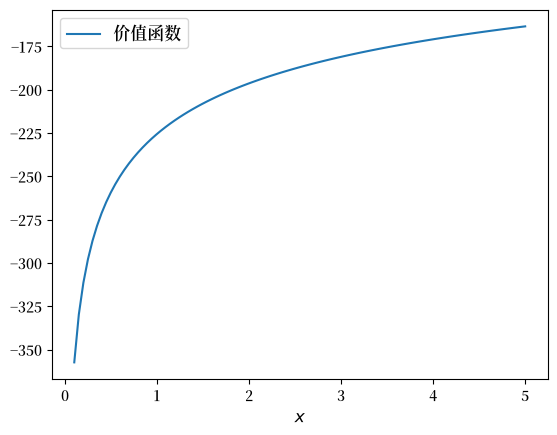

In [4]:
β, γ = 0.95, 1.2
x_grid = np.linspace(0.1, 5, 100)

fig, ax = plt.subplots()

ax.plot(x_grid, v_star(x_grid, β, γ), label='价值函数')

ax.set_xlabel('$x$', fontsize=12)
ax.legend(fontsize=12)

plt.show()

## 最优策略

既然我们已经得到了价值函数 $v^*$，那么在每个状态下计算最优行动就很直接了。

我们应该选择消费以最大化贝尔曼方程{eq}`bellman-cep`的右侧：

$$
    c^* = \arg \max_{0 \leq c \leq x} \{u(c) + \beta v^*(x - c)\}
$$

我们可以将这个最优选择视为状态 $x$ 的**函数**，此时称之为**最优策略**。

我们用 $\sigma^*$ 表示最优策略，因此

$$
    \sigma^*(x) := \arg \max_{c} \{u(c) + \beta v^*(x - c)\}
    \quad \text{对所有 } \; x \geq 0
$$

如果我们将价值函数的解析表达式{eq}`crra_vstar`代入右侧并计算最优值，可以得到

```{math}
:label: crra_opt_pol

    \sigma^*(x) = \left( 1-\beta^{1/\gamma} \right) x
```

现在让我们回顾一下关于参数影响的直觉。

我们之前猜测，消费率会随着这两个参数的增加而减少。

从{eq}`crra_opt_pol`可以看出，事实确实如此。

这里有一些图表来说明。

In [5]:
def c_star(x, β, γ):

    return (1 - β ** (1/γ)) * x

继续使用前面给定的参数 $\beta$ 和 $\gamma$，绘制出的图形如下：

findfont: Failed to find font weight normal, now using 600.


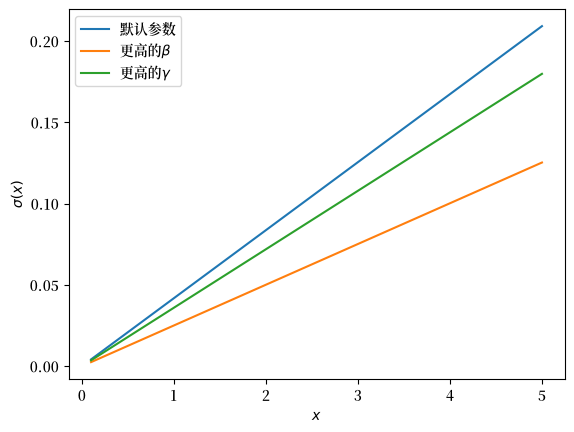

In [6]:
fig, ax = plt.subplots()
ax.plot(x_grid, c_star(x_grid, β, γ), label='默认参数')
ax.plot(x_grid, c_star(x_grid, β + 0.02, γ), label=r'更高的$\beta$')
ax.plot(x_grid, c_star(x_grid, β, γ + 0.2), label=r'更高的$\gamma$')
ax.set_ylabel(r'$\sigma(x)$')
ax.set_xlabel('$x$')
ax.legend()

plt.show()

## 欧拉方程

在上面的讨论中，我们已经在 CRRA 效用的情形下给出了吃蛋糕问题的完整解。

事实上，还有另一种方法可以求解最优策略，即基于所谓的**欧拉方程**。

尽管我们已经得到了完整解，但现在正是研究欧拉方程的好时机。

这是因为，对于更复杂的问题，这个方程能够提供一些通过其他方法难以获得的关键洞见。

### 陈述和含义

当前问题的欧拉方程可以表述为

```{math}
:label: euler-cep

u^{\prime} (c^*_{t})=\beta u^{\prime}(c^*_{t+1})
```

这是最优消费路径 $\{c^*_t\}_{t \geq 0}$ 的必要条件。

它表明，在最优路径上，经过适当折现之后，跨期边际收益是相等的。

这很合理：最优性是通过平滑消费直到没有额外的边际收益为止得到的。

我们也可以用策略函数来表述欧拉方程。

**可行消费策略**是一个满足 $0 \leq \sigma(x) \leq x$ 的映射 $x \mapsto \sigma(x)$。

（这个约束条件表明，我们不能消费超过剩余蛋糕的数量。）

如果一个可行消费策略 $\sigma$ 对于所有 $x > 0$ 满足以下条件，则称其**满足欧拉方程**：

```{math}
:label: euler_pol

u^{\prime}( \sigma(x) )
= \beta u^{\prime} (\sigma(x - \sigma(x)))
```

显然，{eq}`euler_pol`只是{eq}`euler-cep`的策略等价形式。

事实证明，一个可行策略当且仅当满足欧拉方程时才是最优的。

在练习中，你需要验证最优策略{eq}`crra_opt_pol`确实满足这个泛函方程。

```{note}
**泛函方程**是一个未知对象为函数的方程。
```

关于欧拉方程在非常一般情况下充分性的证明，请参见{cite}`ma2020income`中的命题2.2。

下面的论证将聚焦于必要性，解释为什么最优路径或最优策略应当满足欧拉方程。

### 推导 I：扰动法

我们把 $c$ 作为消费路径 $\{c_t\}_{t=0}^\infty$ 的简写。

整个吃蛋糕的最大化问题可以写作

$$
\max_{c \in F} U(c)
\quad \text{其中 } U(c) := \sum_{t=0}^\infty \beta^t u(c_t)
$$

其中 $F$ 是所有可行消费路径的集合。

我们知道，可微函数在极大值点的梯度为零。

因此最优路径 $c^* := \{c^*_t\}_{t=0}^\infty$ 必须满足
$U'(c^*) = 0$。

```{note}
如果你想确切了解导数 $U'(c^*)$ 是如何定义的，考虑到自变量 $c^*$ 是一个无限长的向量，你可以从学习[加托导数](https://baike.baidu.com/item/%E5%8A%A0%E6%89%98%E5%AF%BC%E6%95%B0)开始。不过，下文并不假定需要这些知识。
```

换句话说，对于任何无穷小的（且可行的）偏离最优路径的扰动，$U$ 的变化率必须为零。

因此，考虑这样一个可行的扰动：在 $t$ 期把消费减少为 $c_t^* - h$，并在下一期把消费增加为 $c_{t+1}^* + h$。

在其他时期消费不发生变化。

我们称这种扰动路径为 $c^h$。

根据前面关于零梯度的论证，我们有

$$
\lim_{h \to 0} \frac{U(c^h) - U(c^*)}{h} = U'(c^*) = 0
$$

注意到消费只在 $t$ 和 $t+1$ 时刻发生变化，上式可以写为

$$
\lim_{h \to 0}
\frac{\beta^t u(c^*_t - h) + \beta^{t+1} u(c^*_{t+1} + h)
      - \beta^t u(c^*_t) - \beta^{t+1} u(c^*_{t+1}) }{h} = 0
$$

经过整理，相同的式子可以写作

$$
\lim_{h \to 0}
    \frac{u(c^*_t - h) - u(c^*_t) }{h}
+ \beta \lim_{h \to 0}
    \frac{ u(c^*_{t+1} + h) - u(c^*_{t+1}) }{h} = 0
$$

或者，取极限后得到

$$
- u'(c^*_t) + \beta u'(c^*_{t+1}) = 0
$$

这就是欧拉方程。

### 推导 II：使用贝尔曼方程

另一种推导欧拉方程的方法是使用贝尔曼方程{eq}`bellman-cep`。

```{note}
以下论证假定价值函数是可微的。
关于价值函数可微性的证明，可参见[EDTC](https://johnstachurski.net/edtc.html)的定理10.1.13。
```

对贝尔曼方程右侧关于 $c$ 求导并令其等于零，我们得到

```{math}
:label: bellman_FOC

u^{\prime}(c)=\beta v^{\prime}(x - c)
```

为了得到 $v^{\prime}(x - c)$，我们设
$g(c,x) = u(c) + \beta v(x - c)$，这样，在最优消费选择下，

```{math}
:label: bellman_equality

v(x) = g(c,x)
```

对等式两边求导，同时考虑到最优消费会依赖于 $x$，我们得到

$$
v' (x) =
\frac{\partial }{\partial c} g(c,x) \frac{\partial c}{\partial x}
 + \frac{\partial }{\partial x} g(c,x)
$$

当 $g(c,x)$ 在 $c$ 处取得最大值时，我们有 $\frac{\partial }{\partial c} g(c,x) = 0$。

因此导数简化为

```{math}
:label: bellman_envelope

v' (x) =
\frac{\partial g(c,x)}{\partial x}
= \frac{\partial }{\partial x} \beta v(x - c)
= \beta v^{\prime}(x - c)
```
(这个推导是[包络定理](https://blog.csdn.net/qq_25018077/article/details/123295394)的一个例子。)

但现在应用{eq}`bellman_FOC`得到

```{math}
:label: bellman_v_prime

u^{\prime}(c) = v^{\prime}(x)
```

因此，价值函数的导数等于边际效用。

将这一事实与{eq}`bellman_envelope`结合，就可以得到欧拉方程。

## 练习

```{exercise}
:label: cep_ex1

如何得到{eq}`crra_vstar`和{eq}`crra_opt_pol`中给出的价值函数和最优策略的表达式？

第一步是对消费策略的函数形式作一个猜测。

假设我们不知道解，并从一个假设出发：最优策略是线性的。

换句话说，我们猜测存在一个正的 $\theta$，使得对所有 $t$，设定 $c_t^*=\theta x_t$ 会产生一个最优路径。

从这个猜想出发，尝试获得解 {eq}`crra_vstar` 和 {eq}`crra_opt_pol`。

在此过程中，你需要使用价值函数的定义和贝尔曼方程。
```

```{solution} cep_ex1
:class: dropdown

我们从猜想 $c_t^*=\theta x_t$ 开始，这会导致状态变量（蛋糕大小）的路径为

$$
x_{t+1}=x_t(1-\theta)
$$

那么 $x_t = x_{0}(1-\theta)^t$，因此

$$
\begin{aligned}
v(x_0)
   & = \sum_{t=0}^{\infty} \beta^t u(\theta x_t)\\
   & = \sum_{t=0}^{\infty} \beta^t u(\theta x_0 (1-\theta)^t ) \\
   & = \sum_{t=0}^{\infty} \theta^{1-\gamma} \beta^t (1-\theta)^{t(1-\gamma)} u(x_0) \\
   & = \frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}u(x_{0})
\end{aligned}
$$

从贝尔曼方程可得，

$$
\begin{aligned}
    v(x) & = \max_{0\leq c\leq x}
        \left\{
            u(c) +
            \beta\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}\cdot u(x-c)
        \right\} \\
& = \max_{0\leq c\leq x}
            \left\{
                \frac{c^{1-\gamma}}{1-\gamma} +
                \beta\frac{\theta^{1-\gamma}}
                {1-\beta(1-\theta)^{1-\gamma}}
                \cdot\frac{(x-c)^{1-\gamma}}{1-\gamma}
            \right\}
\end{aligned}
$$

根据一阶条件，我们得到

$$
c^{-\gamma} + \beta\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}\cdot(x-c)^{-\gamma}(-1) = 0
$$

或

$$
c^{-\gamma} = \beta\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}\cdot(x-c)^{-\gamma}
$$

代入 $c = \theta x$ 我们得到

$$
\left(\theta x\right)^{-\gamma} =  \beta\frac{\theta^{1-\gamma}}{1-\beta(1-\theta)^{1-\gamma}}\cdot(x(1-\theta))^{-
\gamma}
$$

经过一些整理得到

$$
\theta = 1-\beta^{\frac{1}{\gamma}}
$$

这证实了我们之前得到的最优策略表达式：

$$
c_t^* = \left(1-\beta^{\frac{1}{\gamma}}\right)x_t
$$

将 $\theta$ 代入上面的价值函数得到

$$
v^*(x_t) = \frac{\left(1-\beta^{\frac{1}{\gamma}}\right)^{1-\gamma}}
{1-\beta\left(\beta^{\frac{{1-\gamma}}{\gamma}}\right)} u(x_t) \\
$$

重新整理得到

$$
v^*(x_t) = \left(1-\beta^\frac{1}{\gamma}\right)^{-\gamma}u(x_t)
$$

我们的论述现已得到验证。
```

```{exercise}
:label: cep_ex2

验证最优策略{eq}`crra_opt_pol`满足欧拉方程{eq}`euler_pol`。
```

```{solution} cep_ex2
:class: dropdown

回顾一下，最优策略为

$$
    \sigma^*(x) = (1 - \beta^{1/\gamma})x
$$

而策略形式下的欧拉方程为

$$
    u'(\sigma(x)) = \beta u'(\sigma(x - \sigma(x)))
$$

对于CRRA效用函数 $u(c) = \frac{c^{1-\gamma}}{1-\gamma}$，边际效用为

$$
    u'(c) = c^{-\gamma}
$$

现在让我们来验证欧拉方程。左边为

$$
    u'(\sigma^*(x)) 
    = [\sigma^*(x)]^{-\gamma} 
    = [(1 - \beta^{1/\gamma})x]^{-\gamma} 
    = (1 - \beta^{1/\gamma})^{-\gamma} x^{-\gamma}
$$

对于右边，我们首先计算下一期的状态：

$$
    x - \sigma^*(x) = x - (1 - \beta^{1/\gamma})x = x\beta^{1/\gamma}
$$

在最优策略下，下一期的消费为

$$
    \sigma^*(x - \sigma^*(x)) = \sigma^*(x\beta^{1/\gamma}) = (1 - \beta^{1/\gamma}) \cdot x\beta^{1/\gamma}
$$

因此，欧拉方程的右边为

$$
\begin{aligned}
\beta u'(\sigma^*(x - \sigma^*(x)))
  &= \beta [(1 - \beta^{1/\gamma}) \cdot x\beta^{1/\gamma}]^{-\gamma} \\
  &= \beta (1 - \beta^{1/\gamma})^{-\gamma} x^{-\gamma} (\beta^{1/\gamma})^{-\gamma} \\
  &= \beta (1 - \beta^{1/\gamma})^{-\gamma} x^{-\gamma} \beta^{-1} \\
  &= (1 - \beta^{1/\gamma})^{-\gamma} x^{-\gamma}
\end{aligned}
$$

由于左边等于右边，最优策略 $\sigma^*$ 满足欧拉方程。
```